# 🗑️ Sistem Sortir Sampah Otomatis
Sistem ini mensimulasikan mesin sortir sampah otomatis berbasis kamera yang mampu mengklasifikasikan sampah ke dalam 5 kelas: Organik, Plastik, Kertas, Logam, dan Kaca.


---


**Improvisasi Pengembangan :**
- GradCAM Visualizer: Visualisasi area gambar paling berpengaruh
- Mobile-optimized Classifier: MobileNetV3 ringan untuk deployment
- Model Explainability Dashboard:  GradCAM + Confusion Matrix + per-class metrics

#1. Install Dependencies
Menginstall semua library Python yang dibutuhkan

In [ ]:
# ─── CELL 1: Install Dependencies ───────────────────────────────────────────
!pip install kaggle gradio onnx onnxruntime torch torchvision torchaudio     --extra-index-url https://download.pytorch.org/whl/cu121 -q
!pip install matplotlib seaborn scikit-learn pillow opencv-python-headless -q
print("✅ Semua dependencies terinstall")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.2 MB/s eta 0:00:00
✅ Semua dependencies terinstall


#2. Import & GPU Check
Mengimpor semua modul yang diperlukan dan memverifikasi ketersediaan GPU.

In [ ]:
# ─── CELL 2: Import & GPU Check ──────────────────────────────────────────────
import os, json, shutil, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder

import cv2
import sklearn.metrics as skm

# GPU check
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🚀 GPU: {gpu_name}  |  VRAM: {vram:.1f} GB")
    print(f"   CUDA: {torch.version.cuda}  |  cuDNN: {torch.backends.cudnn.version()}")
    torch.backends.cudnn.benchmark = True
else:
    print("⚠️  CUDA tidak tersedia, menggunakan CPU")

print(f"\n✅ Device aktif: {DEVICE}")


🚀 GPU: Tesla T4  |  VRAM: 15.6 GB
   CUDA: 12.8  |  cuDNN: 91900

✅ Device aktif: cuda


#3.  Download Dataset dari Kaggle
Mengunduh dataset klasifikasi sampah dari Kaggle secara otomatis.

Dataset yang digunakan yaitu `asdasdasasdas/
garbage-classification`  
Dataset berisi 12 kelas sampah dengan total ribuan gambar.

In [ ]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

!kaggle datasets download -d asdasdasasdas/garbage-classification -p ./data --unzip -q
print("✅ Dataset berhasil didownload")
!find ./data -maxdepth 3 -type d | head -20


Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
✅ Dataset berhasil didownload
./data
./data/garbage classification
./data/garbage classification/Garbage classification
./data/garbage classification/Garbage classification/glass
./data/garbage classification/Garbage classification/paper
./data/garbage classification/Garbage classification/plastic
./data/garbage classification/Garbage classification/trash
./data/garbage classification/Garbage classification/metal
./data/garbage classification/Garbage classification/cardboard
./data/Garbage classification
./data/Garbage classification/Garbage classification
./data/Garbage classification/Garbage classification/glass
./data/Garbage classification/Garbage classification/paper
./data/Garbage classification/Garbage classification/plastic
./data/Garbage classification/Garbage classification/trash
./data/Garbage classification/Garbage classification/metal
./data/Garbage classificatio

#4. Eksplorasi Dataset
Menganalisis struktur dataset dan memetakan kelas
asli ke 5 kelas.

mapping kelas dilakukan dengan Dataset asli memiliki 12 kelas menjadi tepat 5 kelas yang merepresentasikan jenis sampah umum.

Penggabungan kelas (`cardboard + paper → kertas`) adalah teknik umum dalam dataset curation untuk mengurangi granularitas yang tidak diperlukan dan meningkatkan jumlah sampel per kelas.

In [ ]:
DATA_ROOT = Path("./data")

# Cari folder utama dataset
all_dirs = [d for d in DATA_ROOT.rglob("*") if d.is_dir()]
print("Direktori yang ditemukan:")
for d in sorted(all_dirs)[:20]:
    n = len(list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg")))
    if n > 0:
        print(f"  {d.relative_to(DATA_ROOT)} : {n} gambar")

# Dataset ini punya 12 kelas; kita pilih 5 yang merepresentasikan tugas:
CLASS_MAP = {
    # nama_folder_asli : nama_kelas_baru
    "cardboard": "kertas",
    "paper":     "kertas",     # merge ke kertas
    "plastic":   "plastik",
    "metal":     "logam",
    "glass":     "kaca",
    "organic":   "organik",    # food waste / vegetable / fruit
    "food_organic": "organik",
    "vegetation": "organik",
    "trash":     "organik",    # general organic
}
CLASSES = ["organik", "plastik", "kertas", "logam", "kaca"]
print("\n✅ 5 kelas target:", CLASSES)


Direktori yang ditemukan:
  Garbage classification/Garbage classification/cardboard : 403 gambar
  Garbage classification/Garbage classification/glass : 501 gambar
  Garbage classification/Garbage classification/metal : 410 gambar
  Garbage classification/Garbage classification/paper : 594 gambar
  Garbage classification/Garbage classification/plastic : 482 gambar
  Garbage classification/Garbage classification/trash : 137 gambar
  garbage classification/Garbage classification/cardboard : 403 gambar
  garbage classification/Garbage classification/glass : 501 gambar
  garbage classification/Garbage classification/metal : 410 gambar
  garbage classification/Garbage classification/paper : 594 gambar
  garbage classification/Garbage classification/plastic : 482 gambar
  garbage classification/Garbage classification/trash : 137 gambar

✅ 5 kelas target: ['organik', 'plastik', 'kertas', 'logam', 'kaca']


#5. Bangun Dataset Terstruktur (train/val/test split)

- **Train set:** Model belajar dari data
- **Val set:** Memantau overfitting selama training, digunakan untuk menyimpan model terbaik
- **Test set:** Evaluasi objektif performa akhir

In [ ]:
import random
from sklearn.model_selection import train_test_split

DATASET_DIR = Path("./dataset_sampah")
SPLITS = ["train", "val", "test"]
for split in SPLITS:
    for cls in CLASSES:
        (DATASET_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def find_class_folder(root: Path, name: str):
    """Cari folder yang mengandung nama kelas (case-insensitive)."""
    for d in root.rglob("*"):
        if d.is_dir() and name.lower() in d.name.lower():
            imgs = list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg"))
            if len(imgs) > 20:
                return d, imgs
    return None, []

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
COPIES_PER_CLASS = 50  # minimum; akan ambil semua yang tersedia

stats = {}
for src_name, tgt_name in CLASS_MAP.items():
    folder, imgs = find_class_folder(DATA_ROOT, src_name)
    if not folder:
        continue
    existing = stats.get(tgt_name, [])
    existing += imgs
    stats[tgt_name] = existing

print("Jumlah gambar mentah per kelas:")
for cls in CLASSES:
    print(f"  {cls}: {len(stats.get(cls, []))} gambar")

# Split & copy
random.seed(42)
split_stats = defaultdict(lambda: defaultdict(int))

for cls in CLASSES:
    imgs = stats.get(cls, [])
    if not imgs:
        print(f"⚠️  Kelas '{cls}' tidak ditemukan, lewati")
        continue
    random.shuffle(imgs)
    # Batasi 600/kelas agar seimbang
    imgs = imgs[:600]
    tr, tmp = train_test_split(imgs, test_size=0.3, random_state=42)
    va, te = train_test_split(tmp, test_size=0.5, random_state=42)
    for split, lst in [("train", tr), ("val", va), ("test", te)]:
        for i, src in enumerate(lst):
            dst = DATASET_DIR / split / cls / f"{cls}_{i:04d}{src.suffix.lower()}"
            shutil.copy2(src, dst)
            split_stats[split][cls] += 1

print("\nDistribusi split:")
for split in SPLITS:
    total = sum(split_stats[split].values())
    detail = " | ".join(f"{c}:{split_stats[split][c]}" for c in CLASSES)
    print(f"  {split:5s}: {total:4d}  ({detail})")
print("\n✅ Dataset siap")


Jumlah gambar mentah per kelas:
  organik: 137 gambar
  plastik: 482 gambar
  kertas: 997 gambar
  logam: 410 gambar
  kaca: 501 gambar

Distribusi split:
  train: 1489  (organik:95 | plastik:337 | kertas:420 | logam:287 | kaca:350)
  val  :  319  (organik:21 | plastik:72 | kertas:90 | logam:61 | kaca:75)
  test :  322  (organik:21 | plastik:73 | kertas:90 | logam:62 | kaca:76)

✅ Dataset siap


#6. Data Augmentation & DataLoaders
Mendefinisikan pipeline augmentasi data dan membuat DataLoader untuk training, validasi, dan testing.



---
Augmentasi yang diterapkan :


*  `RandomResizedCrop` `scale=(0.6, 1.0)`: Simulasi objek di berbagai jarak/ukuran
*   `RandomHorizontalFlip` `p=0.5 `: Invariansi terhadap orientasi kiri-kanan
*   `RandomVerticalFlip`  `p=0.2`: Simulasi sampah terbalik
*  `RandomRotation` `30°`: Invariansi terhadap sudut pandang kamera
*   `ColorJitter` `brightness, contrast, saturation, hue`: Kondisi pencahayaan berbeda
*  `RandomErasing` `p=0.2` Simulasi occlusion (sampah tertutup sebagian)











Class order: ['kaca', 'kertas', 'logam', 'organik', 'plastik']
Train: 1489 | Val: 319 | Test: 322


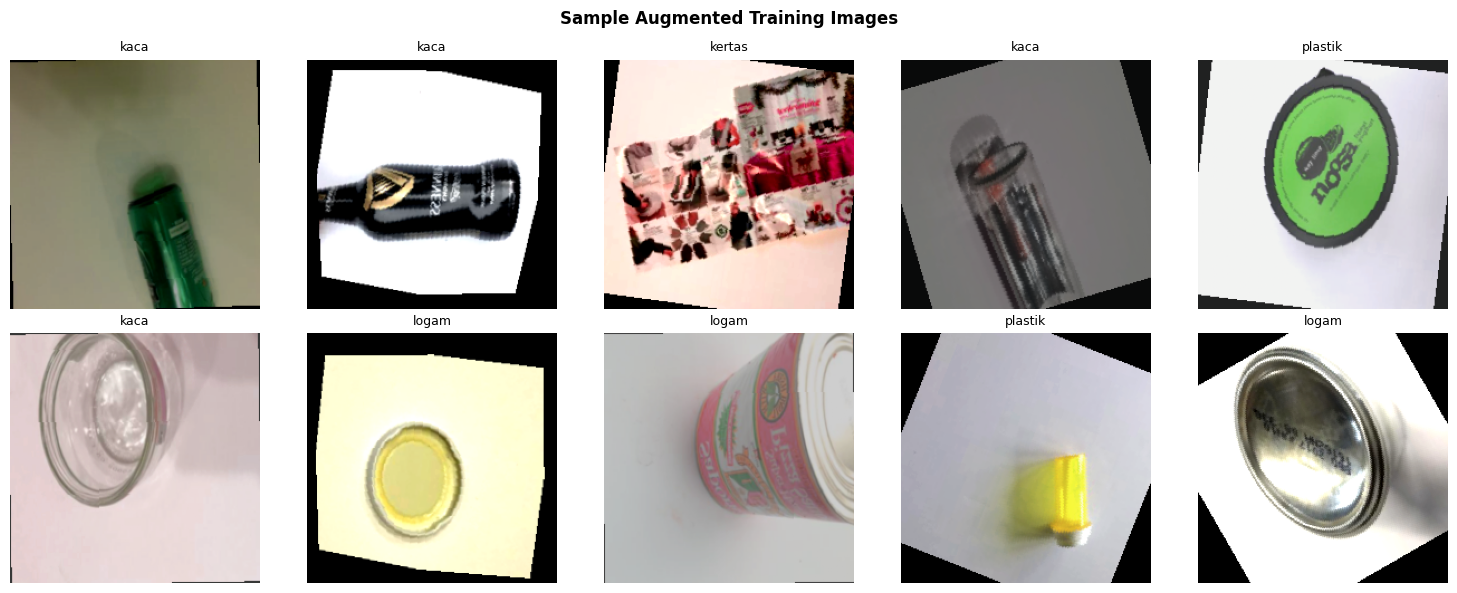

✅ DataLoaders siap


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64  # Tinggi karena GPU; turunkan ke 32 jika OOM

# Augmentasi agresif untuk training
train_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1)),   # Random Erasing augmentation
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(DATASET_DIR / "train", transform=train_tf)
val_ds   = ImageFolder(DATASET_DIR / "val",   transform=val_tf)
test_ds  = ImageFolder(DATASET_DIR / "test",  transform=val_tf)

# Weighted sampler untuk handle imbalance
class_counts = np.array([len(list((DATASET_DIR / "train" / c).glob("*"))) for c in CLASSES])
weights = 1.0 / class_counts
sample_weights = [weights[train_ds.class_to_idx[c]] for _, label in train_ds.samples
                  for c in [train_ds.classes[label]]]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

# Mapping index → nama kelas
IDX2CLASS = {v: k for k, v in train_ds.class_to_idx.items()}
CLASS_NAMES = [IDX2CLASS[i] for i in range(len(CLASSES))]
print("Class order:", CLASS_NAMES)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Preview augmented images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
denorm = T.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                     std=[1/0.229, 1/0.224, 1/0.225])
imgs, labels = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = denorm(imgs[i]).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample Augmented Training Images", fontweight='bold')
plt.tight_layout()
plt.savefig("augmentation_preview.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ DataLoaders siap")


#7. Model — MobileNetV3-Large (Transfer Learning)
Membangun model classifier dengan memanfaatkan pretrained MobileNetV3-Large dari ImageNet.

> **Fase 1 (Epoch 1-5):** Hanya classifier head yang dilatih (backbone dibekukan)

> **Fase 2 (Epoch 6-30):** Seluruh model di-fine-tune dengan LR lebih kecil untuk backbone

In [ ]:
def build_model(num_classes: int, freeze_backbone: bool = True):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        # Freeze semua layer kecuali classifier
        for p in model.features.parameters():
            p.requires_grad = False
        # Unfreeze 3 layer terakhir dari features untuk fine-tuning
        for p in model.features[-3:].parameters():
            p.requires_grad = True

    # Ganti classifier head
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(p=0.3),
        nn.Linear(512, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model

model = build_model(num_classes=len(CLASSES), freeze_backbone=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total_params:.1f}%)")

# Warm-up test
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape   : {out.shape}  → {len(CLASSES)} kelas ✅")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 48.8MB/s]


Total params   : 3,596,597
Trainable params: 2,374,885  (66.0%)
Output shape   : torch.Size([2, 5])  → 5 kelas ✅


#8. Training Loop — GPU Mixed Precision (FP16)

 Melatih model selama 30 epoch.
> Model terbaik (val_acc tertinggi) otomatis disimpan ke `best_model.pth`.  

> Epoch 5: backbone di-unfreeze untuk full fine-tuning.



In [ ]:
NUM_EPOCHS    = 30
LR_HEAD       = 3e-3
LR_BACKBONE   = 3e-4
WARMUP_EPOCHS = 3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = GradScaler()   # Mixed precision scaler

# Optimizer dengan param groups berbeda LR
optimizer = optim.AdamW([
    {"params": model.classifier.parameters(), "lr": LR_HEAD},
    {"params": [p for p in model.features.parameters() if p.requires_grad], "lr": LR_BACKBONE},
], weight_decay=1e-4)

# Cosine Annealing dengan warmup manual
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)

def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
                with autocast():        # FP16
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
CKPT = "best_model.pth"

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | Time")
print("-" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Warmup: linear increase LR
    if epoch <= WARMUP_EPOCHS:
        for g in optimizer.param_groups:
            g["lr"] = g["lr"] * epoch / WARMUP_EPOCHS

    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)

    if epoch > WARMUP_EPOCHS:
        scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    # Unfreeze backbone setelah epoch 5
    if epoch == 5:
        print("\n🔓 Backbone fully unfrozen (fine-tuning mode)")
        for p in model.features.parameters():
            p.requires_grad = True

        # Re-initialize the optimizer to include all unfrozen backbone parameters
        optimizer = optim.AdamW([
            {"params": model.classifier.parameters(), "lr": LR_HEAD},
            {"params": [p for p in model.features.parameters() if p.requires_grad], "lr": LR_BACKBONE}, # Now includes all unfrozen features
        ], weight_decay=1e-4)
        # Re-initialize scheduler as well, or adjust its state if possible
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
        print("✅ Optimizer dan Scheduler diinisialisasi ulang untuk fine-tuning penuh\n")

    cur_lr = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0
    marker = " ★" if va_acc > best_val_acc else ""

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_acc": va_acc, "class_names": CLASS_NAMES}, CKPT)

    print(f"{epoch:5d} | {tr_loss:10.4f} | {tr_acc:9.4f} | {va_loss:8.4f} | {va_acc:7.4f} | {cur_lr:8.2e} | {elapsed:.1f}s{marker}")

print(f"\n✅ Training selesai. Best val acc: {best_val_acc:.4f}")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR | Time
---------------------------------------------------------------------------
    1 |     1.2287 |    0.5944 |   1.1110 |  0.6395 | 1.00e-03 | 48.7s ★
    2 |     0.9344 |    0.7347 |   1.0747 |  0.6646 | 6.67e-04 | 16.0s ★
    3 |     0.7980 |    0.8073 |   0.9154 |  0.7304 | 6.67e-04 | 17.2s ★
    4 |     0.7568 |    0.8375 |   0.8151 |  0.7962 | 6.64e-04 | 18.2s ★

🔓 Backbone fully unfrozen (fine-tuning mode)
✅ Optimizer dan Scheduler diinisialisasi ulang untuk fine-tuning penuh

    5 |     0.7088 |    0.8536 |   0.7607 |  0.8245 | 3.00e-03 | 15.9s ★
    6 |     0.7916 |    0.8274 |   0.9681 |  0.7524 | 2.99e-03 | 97.9s
    7 |     0.6224 |    0.9087 |   0.8181 |  0.8558 | 2.96e-03 | 17.2s ★
    8 |     0.6121 |    0.9066 |   0.7623 |  0.8370 | 2.91e-03 | 18.5s
    9 |     0.5662 |    0.9342 |   0.8096 |  0.8056 | 2.84e-03 | 17.3s
   10 |     0.5437 |    0.9422 |   0.7706 |  0.8370 | 2.75e-03 | 17.2s
   11 |     0.

#9. Plot Training Curves
Memplot grafik loss dan akurasi selama training untuk analisis perilaku model.


---


**Loss Curve:**
- Loss train & val turun: Model belajar dengan baik
- Loss train turun tapi val naik : Overfitting
- Keduanya tidak turun : Underfitting


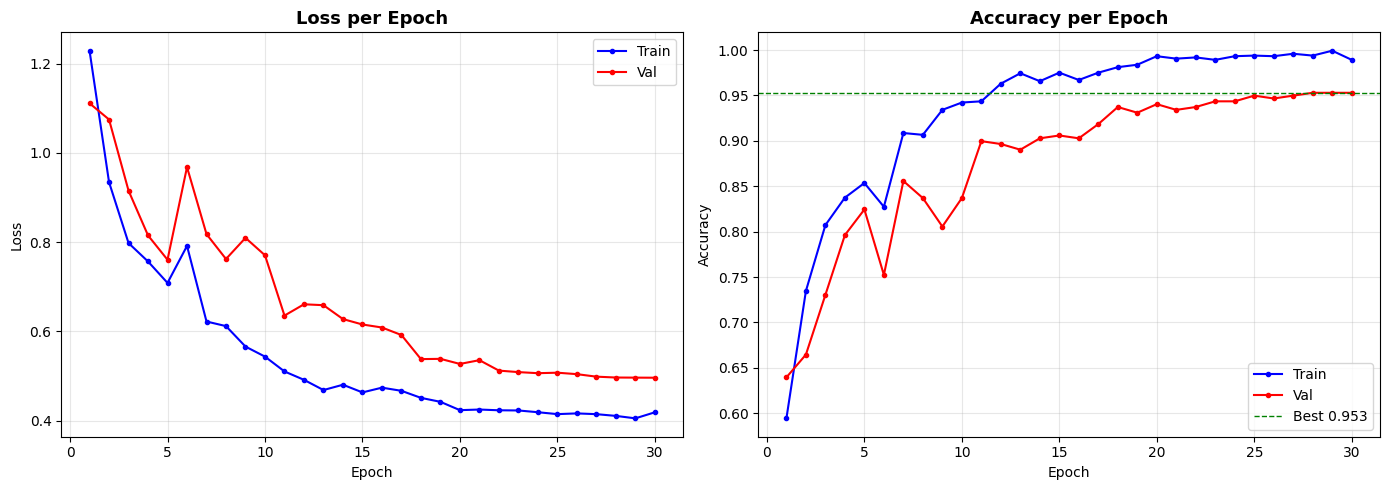

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_x, history["train_loss"], "b-o", ms=3, label="Train")
ax1.plot(epochs_x, history["val_loss"],   "r-o", ms=3, label="Val")
ax1.set_title("Loss per Epoch", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, history["train_acc"], "b-o", ms=3, label="Train")
ax2.plot(epochs_x, history["val_acc"],   "r-o", ms=3, label="Val")
ax2.axhline(best_val_acc, color='green', ls='--', lw=1, label=f"Best {best_val_acc:.3f}")
ax2.set_title("Accuracy per Epoch", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()


 # 10. Evaluasi Model pada Test Set
 Mengukur performa model secara objektif menggunakan data test yang belum pernah dilihat model.


---



Test Accuracy : 0.9037 (90.37%)

              precision    recall  f1-score   support

        kaca       0.91      0.93      0.92        76
      kertas       0.99      0.94      0.97        90
       logam       0.86      0.87      0.86        62
     organik       0.61      0.81      0.69        21
     plastik       0.96      0.88      0.91        73

    accuracy                           0.90       322
   macro avg       0.86      0.89      0.87       322
weighted avg       0.91      0.90      0.91       322



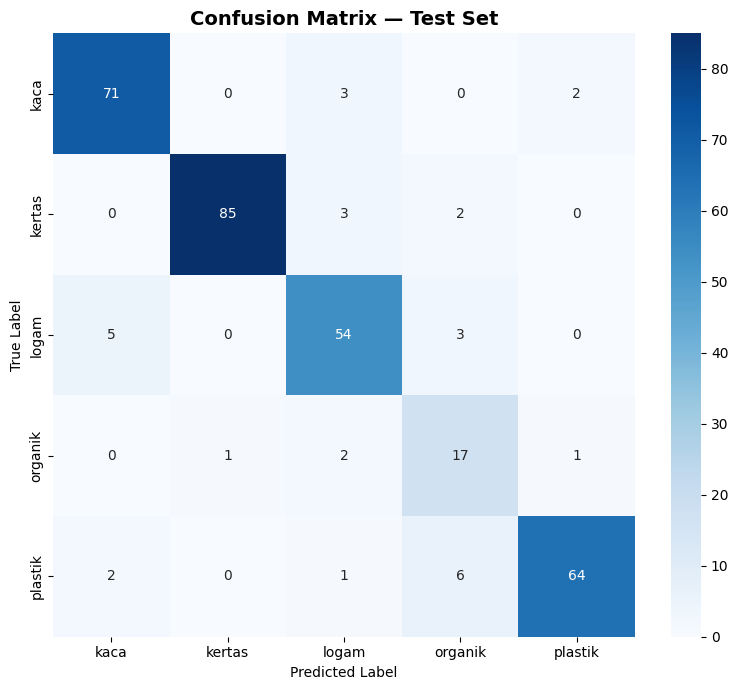

In [ ]:
# Load best checkpoint
ckpt = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast():
            logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print()
print(skm.classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = skm.confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight='bold')
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()


# 11. Grad-CAM — Visualisasi Area Keputusan Model
Memahami "mengapa" model membuat prediksi tertentu dengan memvisualisasikan area gambar yang paling berpengaruh.


---
Apa itu Grad-CAM (Gradient-weighted Class Activation
Mapping)?  
Grad-CAM menggunakan gradien yang mengalir ke layer konvolusi terakhir untuk membuat heatmap yang menunjukkan area mana yang paling penting untuk prediksi.


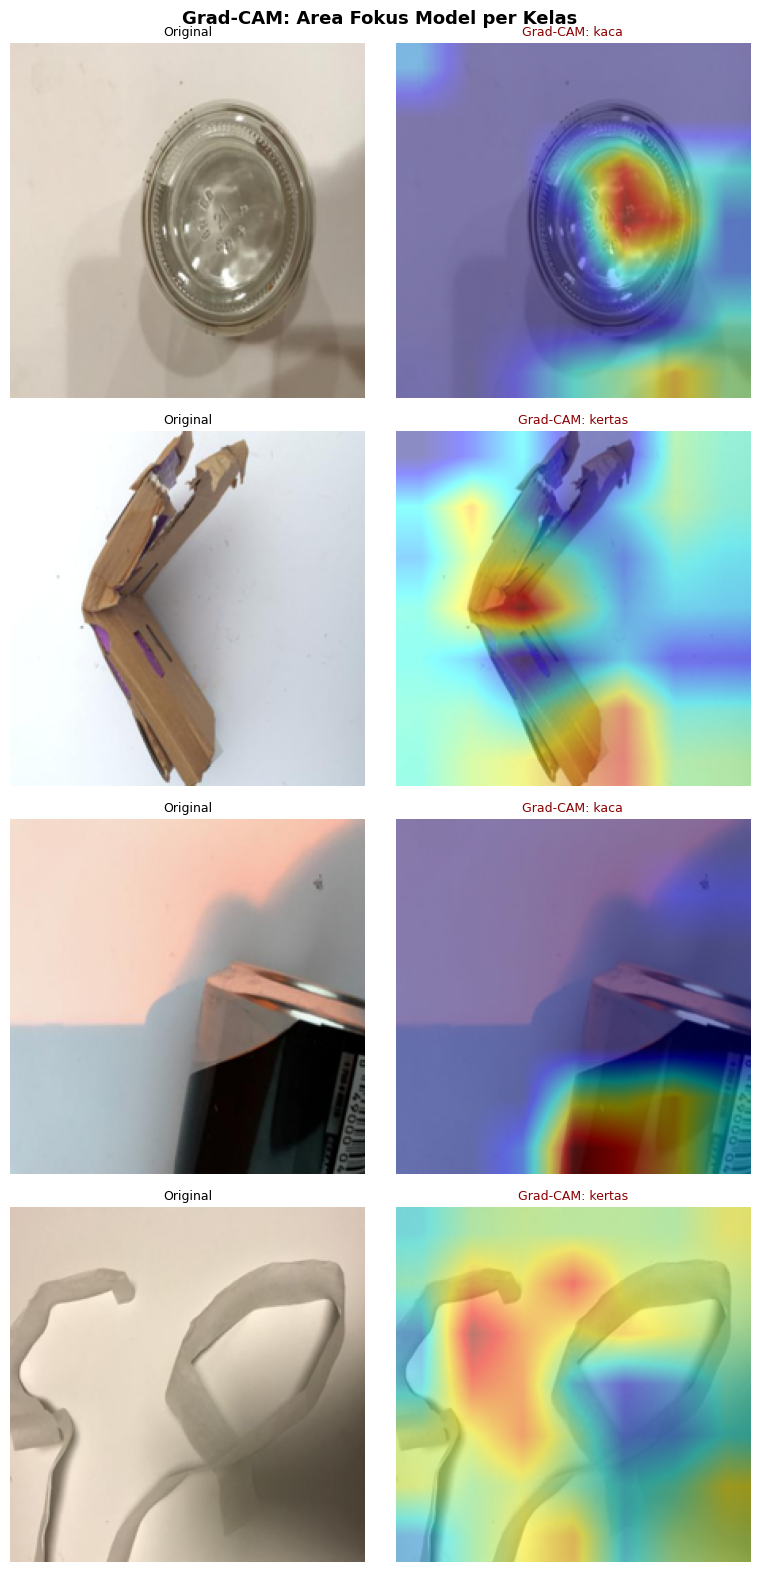

✅ Grad-CAM selesai


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        pooled_grads = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (self.activations * pooled_grads).mean(dim=1).squeeze()
        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx

# Hook pada layer terakhir features MobileNetV3
gradcam = GradCAM(model, model.features[-1][0])  # last conv

def show_gradcam(img_path, ax_orig, ax_cam):
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    tensor  = val_tf(img_pil).unsqueeze(0).to(DEVICE)
    cam, pred_idx = gradcam.generate(tensor)

    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (np.array(img_pil) * 0.55 + heatmap * 0.45).astype(np.uint8)

    ax_orig.imshow(img_pil); ax_orig.set_title("Original", fontsize=9); ax_orig.axis('off')
    ax_cam.imshow(overlay)
    ax_cam.set_title(f"Grad-CAM: {CLASS_NAMES[pred_idx]}", fontsize=9, color='darkred')
    ax_cam.axis('off')

# Pilih 4 gambar dari test set
sample_paths = []
for cls in CLASS_NAMES[:4]:
    imgs_in_cls = list((DATASET_DIR / "test" / cls).glob("*"))
    if imgs_in_cls:
        sample_paths.append((cls, imgs_in_cls[0]))

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(8, 4 * len(sample_paths)))
for i, (cls, p) in enumerate(sample_paths):
    show_gradcam(p, axes[i][0], axes[i][1])
    axes[i][0].set_ylabel(cls, fontsize=10, fontweight='bold')

plt.suptitle("Grad-CAM: Area Fokus Model per Kelas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gradcam.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM selesai")


#12. Sliding Window Multi-Scale + NMS
Mendeteksi dan melokalisasi objek sampah dalam gambar menggunakan teknik sliding window klasik.


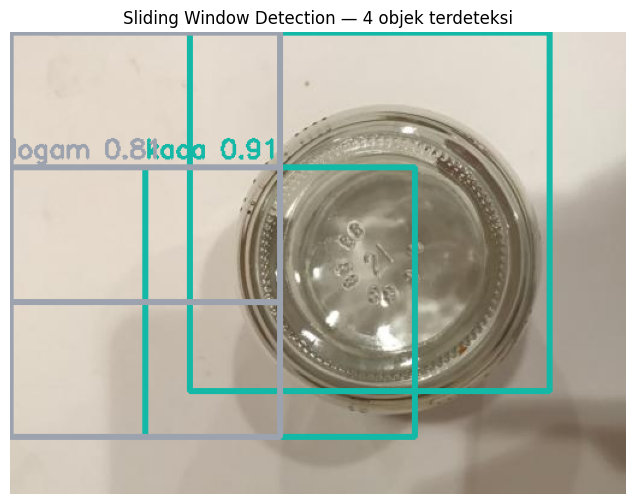

✅ Deteksi: [[149, 0, 448, 298, 'kaca', 0.9267578125], [112, 112, 336, 336, 'kaca', 0.91259765625], [0, 112, 224, 336, 'logam', 0.81103515625], [0, 0, 224, 224, 'logam', 0.71142578125]]


In [ ]:
def preprocess_patch(patch_rgb: np.ndarray) -> torch.Tensor:
    pil = Image.fromarray(patch_rgb)
    return val_tf(pil).unsqueeze(0).to(DEVICE)

def sliding_window_detect(image_path: str,
                           scales=[1.0, 0.75, 0.5],
                           win_size=224, stride=112,
                           conf_thresh=0.70, iou_thresh=0.35):
    """
    Multi-scale sliding window detection.
    Returns list of (x1, y1, x2, y2, class_name, confidence).
    """
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    raw_boxes = []
    model.eval()

    for scale in scales:
        scaled = cv2.resize(img_rgb, (int(W * scale), int(H * scale)))
        sh, sw = scaled.shape[:2]
        for y in range(0, sh - win_size + 1, stride):
            for x in range(0, sw - win_size + 1, stride):
                patch = scaled[y:y+win_size, x:x+win_size]
                tensor = preprocess_patch(patch)
                with torch.no_grad():
                    with autocast():
                        logits = model(tensor)
                    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
                conf = probs.max()
                cls_idx = probs.argmax()
                if conf >= conf_thresh:
                    # Convert back to original image coordinates
                    x1 = int(x / scale); y1 = int(y / scale)
                    x2 = int((x + win_size) / scale); y2 = int((y + win_size) / scale)
                    raw_boxes.append([x1, y1, x2, y2, CLASS_NAMES[cls_idx], float(conf)])

    if not raw_boxes:
        return []

    # ── NMS (Non-Maximum Suppression) ──────────────────────────────────────
    boxes   = np.array([[b[0], b[1], b[2], b[3]] for b in raw_boxes], dtype=float)
    scores  = np.array([b[5] for b in raw_boxes])
    classes = [b[4] for b in raw_boxes]

    keep = []
    indices = scores.argsort()[::-1]
    while len(indices) > 0:
        i = indices[0]
        keep.append(i)
        if len(indices) == 1:
            break
        ious = compute_iou(boxes[i], boxes[indices[1:]])
        indices = indices[1:][ious < iou_thresh]

    return [raw_boxes[i] for i in keep]

def compute_iou(box, boxes):
    x1 = np.maximum(box[0], boxes[:, 0])
    y1 = np.maximum(box[1], boxes[:, 1])
    x2 = np.minimum(box[2], boxes[:, 2])
    y2 = np.minimum(box[3], boxes[:, 3])
    inter = np.maximum(0, x2-x1) * np.maximum(0, y2-y1)
    area1 = (box[2]-box[0]) * (box[3]-box[1])
    area2 = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    return inter / (area1 + area2 - inter + 1e-8)

CLASS_COLORS = {
    "organik": (34, 197, 94),
    "plastik": (59, 130, 246),
    "kertas":  (234, 179, 8),
    "logam":   (156, 163, 175),
    "kaca":    (20, 184, 166),
}

def draw_detections(image_path: str, detections: list, save_path: str = None):
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    for x1, y1, x2, y2, cls, conf in detections:
        color = CLASS_COLORS.get(cls, (255, 0, 0))
        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 3)
        label = f"{cls} {conf:.2f}"
        cv2.putText(img_rgb, label, (x1, y1-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    if save_path:
        cv2.imwrite(save_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    return img_rgb

# Demo sliding window pada gambar test
demo_cls = CLASS_NAMES[0]
demo_imgs = list((DATASET_DIR / "test" / demo_cls).glob("*"))
if demo_imgs:
    dets = sliding_window_detect(demo_imgs[0])
    result_img = draw_detections(demo_imgs[0], dets, "sw_demo.png")

    plt.figure(figsize=(8, 6))
    plt.imshow(result_img)
    plt.title(f"Sliding Window Detection — {len(dets)} objek terdeteksi", fontsize=12)
    plt.axis('off')
    plt.savefig("sliding_window_result.png", dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✅ Deteksi: {dets}")


#13. Statistik Jumlah Per Jenis Sampah
Memvisualisasikan distribusi prediksi model pada test set dalam bentuk bar chart dan pie chart.



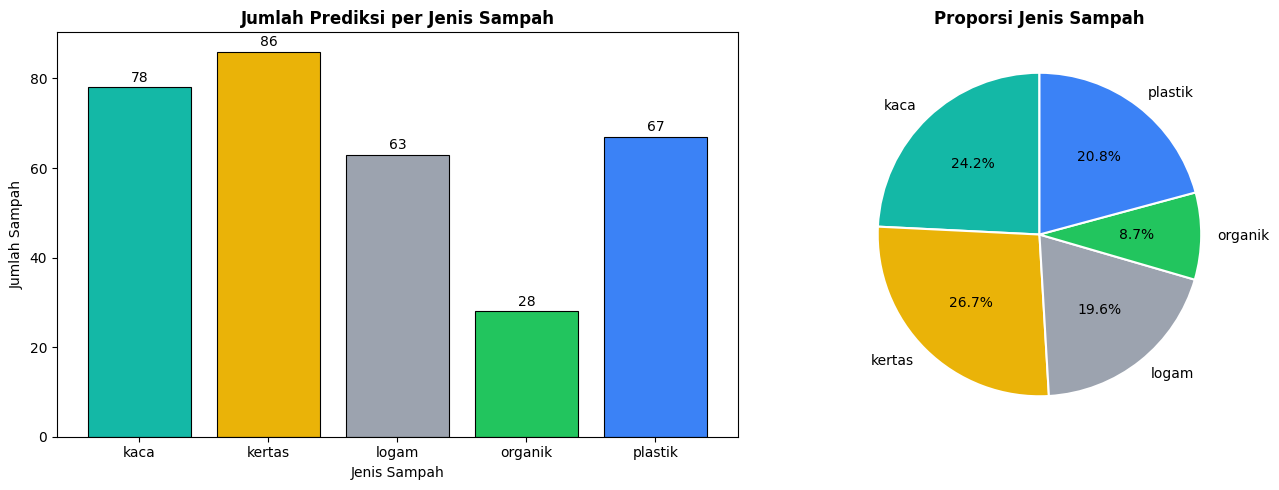


Statistik Detail:
Kelas        |  Prediksi |  Aktual |  Selisih
------------------------------------------
kaca         |        78 |      76 |       +2
kertas       |        86 |      90 |       -4
logam        |        63 |      62 |       +1
organik      |        28 |      21 |       +7
plastik      |        67 |      73 |       -6


In [ ]:
from collections import Counter
import matplotlib.patches as mpatches

# Prediksi seluruh test set
preds_counter = Counter(CLASS_NAMES[p] for p in all_preds)
true_counter  = Counter(CLASS_NAMES[l] for l in all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart predicted
bars = axes[0].bar(CLASS_NAMES,
                   [preds_counter[c] for c in CLASS_NAMES],
                   color=[np.array(CLASS_COLORS[c])/255 for c in CLASS_NAMES],
                   edgecolor='black', linewidth=0.8)
axes[0].set_title("Jumlah Prediksi per Jenis Sampah", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Jumlah Sampah")
axes[0].set_xlabel("Jenis Sampah")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie([preds_counter[c] for c in CLASS_NAMES],
            labels=CLASS_NAMES,
            colors=[np.array(CLASS_COLORS[c])/255 for c in CLASS_NAMES],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Proporsi Jenis Sampah", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("statistics.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nStatistik Detail:")
print(f"{'Kelas':<12} | {'Prediksi':>9} | {'Aktual':>7} | {'Selisih':>8}")
print("-" * 42)
for c in CLASS_NAMES:
    p, a = preds_counter[c], true_counter[c]
    print(f"{c:<12} | {p:>9} | {a:>7} | {p-a:>+8}")


#14. Export Model ke ONNX
Mengkonversi model PyTorch ke format ONNX (Open Neural Network Exchange) untuk deployment lintas platform.

In [ ]:
!pip install onnxscript -q # Add this line to install the missing module
import os, json, time
import numpy as np
import torch
import onnx
import onnxruntime as ort
import torchvision.models as models # Import here for build_model function
import torch.nn as nn # Import here for build_model function

# --- Helper function for model building (copied from Cell 7 for self-containment) ---
def build_model(num_classes: int, freeze_backbone: bool = True):
    # Ensure MobileNet_V3_Large_Weights is available
    from torchvision.models import MobileNet_V3_Large_Weights
    model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
        for p in model.features[-3:].parameters():
            p.requires_grad = True

    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(p=0.3),
        nn.Linear(512, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model
# ----------------------------------------------------------------------------------

# ── Guard: rebuild jika variabel belum ada di session ──
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define these unconditionally to ensure they are always available as fallbacks
_CLASS_NAMES_TO_USE = globals().get("CLASS_NAMES", ["organik", "plastik", "kertas", "logam", "kaca"])
_CKPT_FILE_TO_USE = globals().get("CKPT", "best_model.pth")

if "model" not in dir() or model is None:
    model = build_model(num_classes=len(_CLASS_NAMES_TO_USE), freeze_backbone=False).to(DEVICE)

    if os.path.exists(_CKPT_FILE_TO_USE):
        state = torch.load(_CKPT_FILE_TO_USE, map_location=DEVICE)
        if isinstance(state, dict) and "model_state" in state:
            model.load_state_dict(state["model_state"])
        else:
            model.load_state_dict(state)
        print(f"✅ Checkpoint dimuat dari {_CKPT_FILE_TO_USE}")
    else:
        print(f"⚠️  Checkpoint '{_CKPT_FILE_TO_USE}' tidak ditemukan — model pakai bobot acak")

    model = model.to(DEVICE)
    print(f"✅ Model diinisialisasi ulang | device: {DEVICE}")
else:
    # If 'model' is already loaded and defined from previous cells (like Cell 10),
    # ensure it's in evaluation mode for ONNX export.
    model.eval()

# ── Lanjut ke export ONNX seperti biasa ──
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
ONNX_PATH = "sampah_classifier.onnx"

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=18, # Changed opset_version from 17 to 18
    do_constant_folding=True,
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
)
print(f"✅ Model diekspor ke {ONNX_PATH}")

# Validasi ONNX
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("✅ ONNX model valid")

# Benchmark inference ONNX vs PyTorch
sess = ort.InferenceSession(ONNX_PATH, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
np_input = np.random.randn(1, 3, 224, 224).astype(np.float32)

# PyTorch inference time
t0 = time.time()
for _ in range(50):
    with torch.no_grad():
        model(torch.from_numpy(np_input).to(DEVICE))
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
pt_ms = (time.time() - t0) * 1000 / 50

# ONNX Runtime inference time
t0 = time.time()
for _ in range(50):
    sess.run(None, {"image": np_input})
ort_ms = (time.time() - t0) * 1000 / 50

print(f"\nBenchmark (avg 50 runs):")
print(f"  PyTorch {'GPU' if DEVICE.type == 'cuda' else 'CPU'}: {pt_ms:.2f} ms/img")
print(f"  ONNX Runtime : {ort_ms:.2f} ms/img")
print(f"  Speedup      : {pt_ms/ort_ms:.2f}x")

# Save class names
with open("class_names.json", "w") as f:
    json.dump(globals().get("CLASS_NAMES", _CLASS_NAMES_TO_USE), f)
print("\n✅ class_names.json tersimpan")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.2 MB/s eta 0:00:00
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ Model diekspor ke sampah_classifier.onnx
✅ ONNX model valid

Benchmark (avg 50 runs):
  PyTorch GPU: 6.80 ms/img
  ONNX Runtime : 7.66 ms/img
  Speedup      : 0.89x

✅ class_names.json tersimpan


#15. Gradio Interactive UI
Membuat antarmuka web interaktif untuk demo klasifikasi sampah secara real-time menggunakan ONNX Runtime.

In [ ]:
import gradio as gr
from collections import defaultdict

# Session statistics (reset per Gradio session)
session_stats = defaultdict(int)
history_log   = []

# ONNX session sudah dibuat di Cell 14 (variabel `sess`)

CLASS_EMOJI = {
    "organik": "🌿", "plastik": "🧴", "kertas": "📄",
    "logam":   "🔩", "kaca":    "🪟"
}

def classify_image(image: Image.Image):
    """Klasifikasi single image menggunakan ONNX Runtime."""
    if image is None:
        return "Tidak ada gambar", None, "Upload gambar terlebih dahulu"

    # Preprocess
    img_resized = image.resize((224, 224)).convert("RGB")
    tensor = val_tf(img_resized).unsqueeze(0).numpy().astype(np.float32)

    # ONNX inference
    logits = sess.run(None, {"image": tensor})[0][0]
    probs  = np.exp(logits) / np.exp(logits).sum()
    pred_idx = probs.argmax()
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    # Update session stats
    session_stats[pred_cls] += 1
    history_log.append(f"{pred_cls} ({confidence:.1%})")

    # Format hasil
    emoji = CLASS_EMOJI[pred_cls]
    result_text = f"## {emoji} {pred_cls.upper()}\n\n"
    result_text += f"**Confidence:** {confidence:.1%}\n\n"
    result_text += "---\n### Probabilitas Semua Kelas:\n"
    sorted_idx = probs.argsort()[::-1]
    for i in sorted_idx:
        bar_len = int(probs[i] * 20)
        bar = "█" * bar_len + "░" * (20 - bar_len)
        result_text += f"- **{CLASS_NAMES[i]:8s}**: {bar} {probs[i]:.1%}\n"

    # Statistics chart
    fig, ax = plt.subplots(figsize=(6, 3))
    if any(session_stats.values()):
        cls_list = CLASS_NAMES
        counts   = [session_stats[c] for c in cls_list]
        colors   = [np.array(CLASS_COLORS[c])/255 for c in cls_list]
        bars = ax.bar(cls_list, counts, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_title("Statistik Sesi Ini", fontsize=11, fontweight='bold')
        ax.set_ylabel("Jumlah")
        for b in bars:
            if b.get_height() > 0:
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                        str(int(b.get_height())), ha='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, "Belum ada data", ha='center', va='center', transform=ax.transAxes)
    ax.set_ylim(bottom=0)
    plt.tight_layout()

    # History text
    recent = history_log[-10:][::-1]
    hist_text = "### 📋 Riwayat (10 terakhir):\n" + "\n".join(f"- {h}" for h in recent)

    return result_text, fig, hist_text

def reset_stats():
    session_stats.clear()
    history_log.clear()
    return "Statistik direset ✅", None, ""

# Build Gradio UI
with gr.Blocks(title="🗑️ Sistem Sortir Sampah Otomatis", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🗑️ Sistem Klasifikasi Sampah Otomatis
    ### Powered by MobileNetV3 + Sliding Window Detection | GPU Accelerated
    Upload gambar sampah untuk mengetahui jenisnya secara otomatis.
    **Kelas:** 🌿 Organik | 🧴 Plastik | 📄 Kertas | 🔩 Logam | 🪟 Kaca
    """)

    with gr.Row():
        with gr.Column(scale=1):
            img_input  = gr.Image(type="pil", label="Upload Gambar Sampah", height=300)
            with gr.Row():
                classify_btn = gr.Button("🔍 Klasifikasi", variant="primary", scale=3)
                reset_btn    = gr.Button("🔄 Reset", scale=1)
            gr.Examples(
                examples=[[str(p)] for cls in CLASS_NAMES
                          for p in list((DATASET_DIR/"test"/cls).glob("*"))[:2]],
                inputs=img_input,
                label="Contoh Gambar"
            )

        with gr.Column(scale=1):
            result_out = gr.Markdown(label="Hasil Klasifikasi")
            stats_plot = gr.Plot(label="Statistik Sesi")
            history_out = gr.Markdown(label="Riwayat")

    classify_btn.click(classify_image,  inputs=img_input, outputs=[result_out, stats_plot, history_out])
    reset_btn.click(reset_stats, inputs=None, outputs=[result_out, stats_plot, history_out])

demo.launch(share=True) # Removed server_port=7860 to let Gradio find an available port

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e1549a6442f7aee964.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#16. Real-Time Webcam Classification1
Mengklasifikasikan sampah secara real-time langsung dari kamera webcam.


In [ ]:
RUN_WEBCAM = False  # Set True untuk aktifkan

if RUN_WEBCAM:
    cap = cv2.VideoCapture(0)
    print("📷 Webcam aktif. Tekan 'q' untuk keluar.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_pil   = Image.fromarray(frame_rgb)
        tensor    = val_tf(img_pil).unsqueeze(0).numpy().astype(np.float32)

        logits = sess.run(None, {"image": tensor})[0][0]
        probs  = np.exp(logits) / np.exp(logits).sum()
        idx    = probs.argmax()
        cls    = CLASS_NAMES[idx]
        conf   = probs[idx]

        color = CLASS_COLORS.get(cls, (255, 255, 255))
        label = f"{CLASS_EMOJI[cls]} {cls}: {conf:.1%}"
        cv2.putText(frame, label, (15, 40),
                    cv2.FONT_HERSHEY_DUPLEX, 1.2, color[::-1], 2)
        cv2.rectangle(frame, (10, 10), (frame.shape[1]-10, 65), color[::-1], 2)

        cv2.imshow("Sistem Sortir Sampah Otomatis", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("✅ Webcam ditutup")
else:
    print("ℹ️  Mode webcam nonaktif. Gunakan Gradio UI di Cell 15.")


ℹ️  Mode webcam nonaktif. Gunakan Gradio UI di Cell 15.


In [ ]:
import zipfile
from google.colab import files
import os

output_files = [
    "best_model.pth",
    "sampah_classifier.onnx",
    "class_names.json",
    "training_curves.png",
    "confusion_matrix.png",
    "gradcam.png",
    "statistics.png",
    "augmentation_preview.png",
    "sliding_window_result.png" # Include the sliding window result image
]

zip_filename = "output_sampah_classifier.zip"

with zipfile.ZipFile(zip_filename, 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"✅ Menambahkan {f} ke {zip_filename}")
        else:
            print(f"⚠️  File {f} tidak ditemukan, dilewati")

print(f"\n✅ File '{zip_filename}' berhasil dibuat. Mengunduh...")
files.download(zip_filename)

✅ Menambahkan best_model.pth ke output_sampah_classifier.zip
✅ Menambahkan sampah_classifier.onnx ke output_sampah_classifier.zip
✅ Menambahkan class_names.json ke output_sampah_classifier.zip
✅ Menambahkan training_curves.png ke output_sampah_classifier.zip
✅ Menambahkan confusion_matrix.png ke output_sampah_classifier.zip
✅ Menambahkan gradcam.png ke output_sampah_classifier.zip
✅ Menambahkan statistics.png ke output_sampah_classifier.zip
✅ Menambahkan augmentation_preview.png ke output_sampah_classifier.zip
✅ Menambahkan sliding_window_result.png ke output_sampah_classifier.zip

✅ File 'output_sampah_classifier.zip' berhasil dibuat. Mengunduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>